# Kernel Regression: From Linear to Nonlinear Modeling

## 1. Linear Regression Foundation

The goal of regression is to predict a continuous output $y$ from input features $\mathbf{x} = (x_1, x_2, ..., x_d)^T$ using a learned function $f$:

$$
y = f(\mathbf{x}) + \varepsilon
$$

where $\varepsilon$ represents random noise.

In **linear regression**, we assume $f$ is linear:

$$
f(\mathbf{x}) = \mathbf{w}^T \mathbf{x}
$$

(The bias term can be absorbed into $\mathbf{w}$ by adding a constant $1$ to $\mathbf{x}$.)

The parameters $\mathbf{w}$ minimize the **sum of squared errors**:

$$
\min_{\mathbf{w}} \sum_{i=1}^n (y_i - \mathbf{w}^T \mathbf{x}_i)^2
$$

---

## 2. Kernel Regression: The Core Idea

### 2.1 Why Kernels?

Real-world data often has **nonlinear patterns** that linear models cannot capture. The solution: map each input $\mathbf{x}$ to a higher-dimensional feature space $\phi(\mathbf{x})$ where the relationship becomes linear:

$$
f(\mathbf{x}) = \mathbf{w}^T \phi(\mathbf{x})
$$

**The Challenge**: Explicitly computing $\phi(\mathbf{x})$ may be computationally prohibitive or even infinite-dimensional.

**The Kernel Trick**: Use a **kernel function** $K$ that computes dot products in the feature space without ever constructing $\phi(\mathbf{x})$ explicitly:

$$
K(\mathbf{x}_i, \mathbf{x}_j) = \langle \phi(\mathbf{x}_i), \phi(\mathbf{x}_j) \rangle
$$

---

### 2.2 The Dual Formulation

Using the kernel trick, the regression function becomes a **weighted sum of kernel similarities** to each training point:

$$
\hat{y}(\mathbf{x}) = \sum_{i=1}^n \alpha_i \, K(\mathbf{x}, \mathbf{x}_i)
$$

where:
- $\alpha_i$ are **weights** learned from data
- $K(\mathbf{x}, \mathbf{x}_i)$ measures similarity between the test point $\mathbf{x}$ and training point $\mathbf{x}_i$

**Interpretation**: The prediction is a similarity-weighted average of training outputs, where the weights $\alpha_i$ are learned rather than being simple averages.

---

## 3. Training: Solving for $\boldsymbol{\alpha}$

### 3.1 The Optimization Problem

We learn $\alpha_i$ by fitting the training data:

$$
\min_{\boldsymbol{\alpha}} \sum_{j=1}^n \left( y_j - \sum_{i=1}^n \alpha_i K(\mathbf{x}_j, \mathbf{x}_i) \right)^2
$$

### 3.2 Matrix Formulation

Define:
- **Kernel matrix** $\mathbf{K}$ (size $n \times n$): $\mathbf{K}_{ij} = K(\mathbf{x}_i, \mathbf{x}_j)$
- **Weight vector** $\boldsymbol{\alpha} = [\alpha_1, ..., \alpha_n]^T$
- **Output vector** $\mathbf{y} = [y_1, ..., y_n]^T$

For all training points, predictions are:

$$
\hat{\mathbf{y}} = \mathbf{K} \boldsymbol{\alpha}
$$

The sum of squared errors becomes:

$$
\|\mathbf{y} - \mathbf{K} \boldsymbol{\alpha}\|^2
$$

### 3.3 The Solution

Taking the derivative and setting to zero:

$$
\frac{\partial}{\partial \boldsymbol{\alpha}} \|\mathbf{y} - \mathbf{K} \boldsymbol{\alpha}\|^2 = -2\mathbf{K}^T(\mathbf{y} - \mathbf{K}\boldsymbol{\alpha}) = 0
$$

Since $\mathbf{K}$ is symmetric ($\mathbf{K}^T = \mathbf{K}$):

$$
\mathbf{K}(\mathbf{y} - \mathbf{K}\boldsymbol{\alpha}) = 0
$$

$$
\mathbf{K}\mathbf{y} = \mathbf{K}^2\boldsymbol{\alpha}
$$

If $\mathbf{K}$ is invertible (positive definite kernel with distinct points), multiply by $\mathbf{K}^{-1}$:

$$
\mathbf{y} = \mathbf{K}\boldsymbol{\alpha}
$$

Thus:

$$
\boxed{\boldsymbol{\alpha} = \mathbf{K}^{-1} \mathbf{y}}
$$

**Key Insight**: The weights $\boldsymbol{\alpha}$ are chosen so that training predictions perfectly match training outputs ($\hat{\mathbf{y}}_{\text{train}} = \mathbf{y}$). This is **exact interpolation**.

---

## 4. Making Predictions on New Data

### 4.1 Single Test Point

For a new test point $\mathbf{x}_{\text{test}}$ (not in training set):

**Step 1**: Compute kernel similarities between $\mathbf{x}_{\text{test}}$ and **all training points**:

$$
\mathbf{k}_{\text{test}} = 
\begin{bmatrix}
K(\mathbf{x}_{\text{test}}, \mathbf{x}_1) \\
K(\mathbf{x}_{\text{test}}, \mathbf{x}_2) \\
\vdots \\
K(\mathbf{x}_{\text{test}}, \mathbf{x}_n)
\end{bmatrix}
\quad \text{(size } n \times 1\text{)}
$$

**Step 2**: Make prediction using the same formula:

$$
\hat{y}_{\text{test}} = \sum_{i=1}^n \alpha_i K(\mathbf{x}_{\text{test}}, \mathbf{x}_i) = \mathbf{k}_{\text{test}}^T \boldsymbol{\alpha}
$$

### 4.2 Multiple Test Points

For $m$ test points $\{\mathbf{x}_{\text{test}}^{(1)}, \dots, \mathbf{x}_{\text{test}}^{(m)}\}$:

Define $\mathbf{K}_{\text{test}}$ as an $m \times n$ matrix:

$$
[\mathbf{K}_{\text{test}}]_{pj} = K(\mathbf{x}_{\text{test}}^{(p)}, \mathbf{x}_j)
$$

Then predictions:

$$
\hat{\mathbf{y}}_{\text{test}} = \mathbf{K}_{\text{test}} \, \boldsymbol{\alpha}
$$

### 4.3 Training vs. Testing Summary

| Phase | Input | Prediction | Equals true $y$? |
|-------|-------|------------|-------------------|
| **Training** | $\mathbf{K}$ ($n \times n$) | $\hat{\mathbf{y}}_{\text{train}} = \mathbf{K}\boldsymbol{\alpha}$ | Yes (exact fit) |
| **Testing** | $\mathbf{k}_{\text{test}}$ ($n \times 1$) | $\hat{y}_{\text{test}} = \mathbf{k}_{\text{test}}^T \boldsymbol{\alpha}$ | No (generalization) |

**Important**: The interpolation property $\hat{\mathbf{y}}_{\text{train}} = \mathbf{y}$ holds **only for training data**. For test points, predictions are determined by similarity to training points, not by exact matching.

---

## 5. The Pseudoinverse Connection

### 5.1 Unified View

From the matrix appendix, recall the pseudoinverse $X^+$ solves $X\mathbf{w} = \mathbf{y}$ optimally. For kernel regression, we solve $\mathbf{K}\boldsymbol{\alpha} = \mathbf{y}$, so:

$$
\boldsymbol{\alpha} = \mathbf{K}^+ \mathbf{y}
$$

When $\mathbf{K}$ is invertible, $\mathbf{K}^+ = \mathbf{K}^{-1}$. When $\mathbf{K}$ is singular or ill-conditioned, we use regularization.

### 5.2 Regularization (Kernel Ridge Regression)

In practice, with noisy data, exact interpolation leads to overfitting. Add a ridge penalty $\lambda \|\mathbf{f}\|^2$:

$$
\min_{\boldsymbol{\alpha}} \|\mathbf{y} - \mathbf{K}\boldsymbol{\alpha}\|^2 + \lambda \boldsymbol{\alpha}^T \mathbf{K} \boldsymbol{\alpha}
$$

The solution becomes:

$$
\boxed{\boldsymbol{\alpha} = (\mathbf{K} + \lambda \mathbf{I})^{-1} \mathbf{y}}
$$

This is the **kernel ridge regression** estimator. The regularization term:
- Improves numerical stability (ensures invertibility)
- Prevents overfitting by shrinking weights
- Controls the smoothness of the prediction function

---

**Practice**

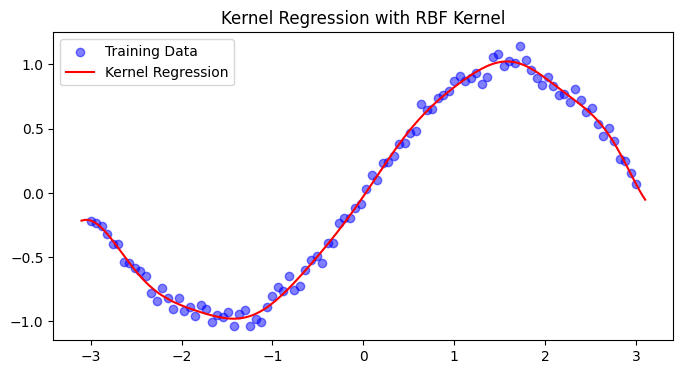

In [29]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
import matplotlib.pyplot as plt

# Generate synthetic data
X = np.linspace(-3, 3, 100)[:, None]
y = np.sin(X).ravel() + 0.05*np.random.randn(100)

# Compute RBF kernel (σ=1.0)
K = rbf_kernel(X, X, gamma=0.5)

# Solve for coefficients (with small regularization)
alpha = np.linalg.solve(K + 1e-6*np.eye(len(X)), y)

# Predict new points
X_test = np.linspace(-3.1, 3.1, 200)[:, None]
K_test = rbf_kernel(X_test, X, gamma=0.5)
y_pred = K_test @ alpha

# Plot results
plt.figure(figsize=(8, 4))
plt.scatter(X, y, color='blue', label='Training Data', alpha=0.5)
plt.plot(X_test, y_pred, color='red', label='Kernel Regression')
plt.title('Kernel Regression with RBF Kernel')
plt.legend()
plt.show()

## 6. The effects of regularization and noise levels on kernel regression

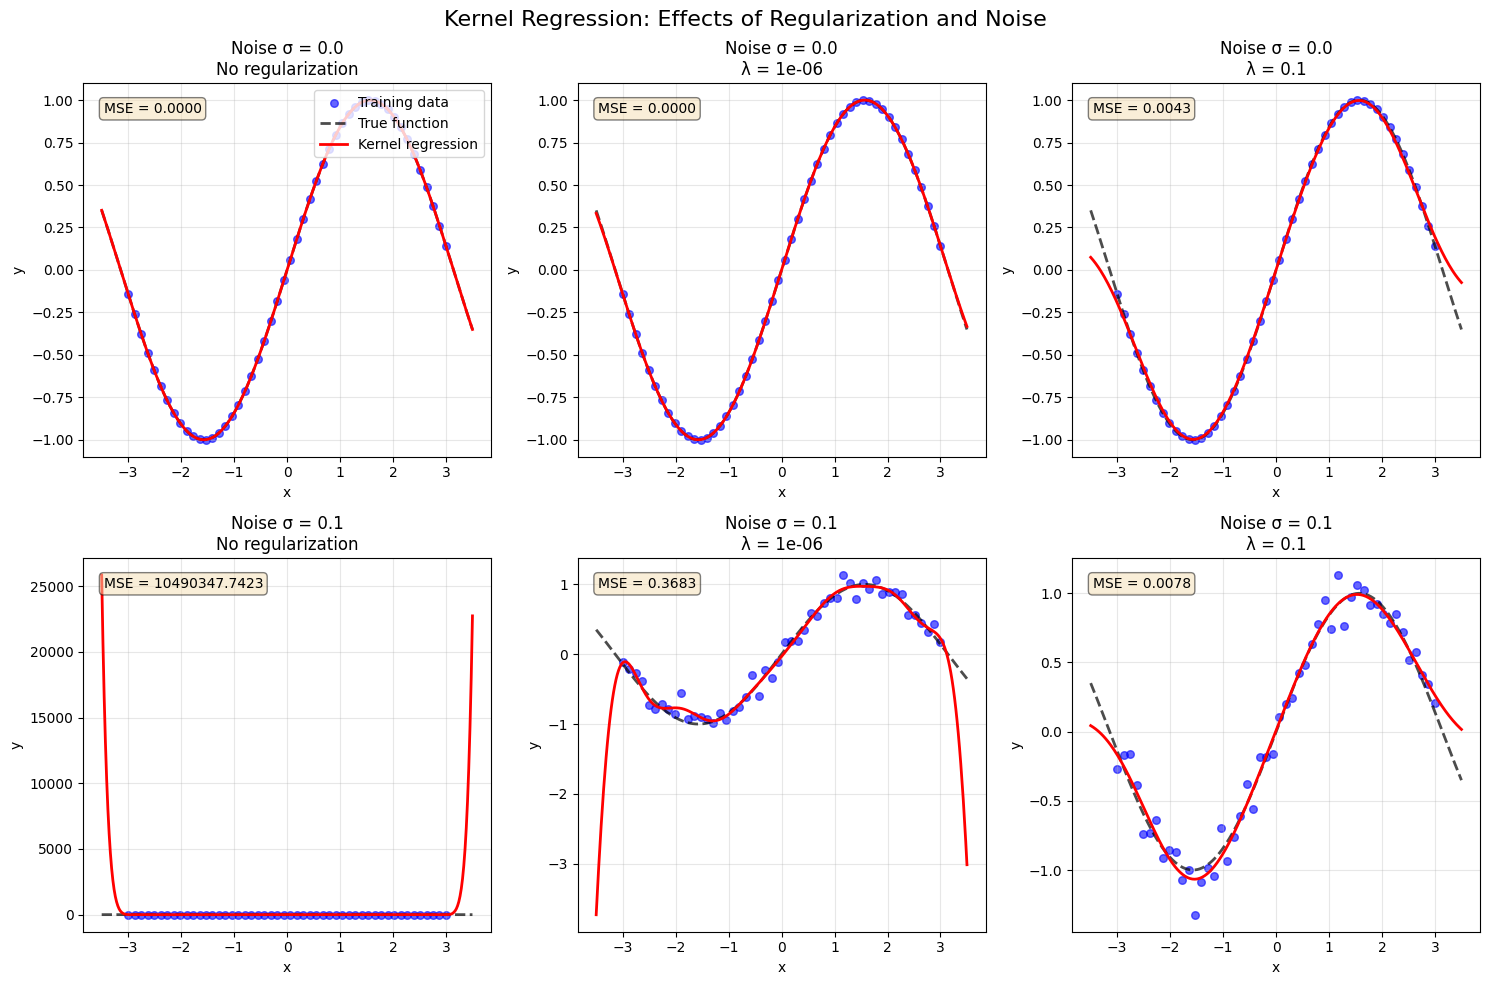


SUMMARY: Test MSE for different noise levels and regularization
Noise σ    λ = 0                λ = 1e-6             λ = 0.1             
----------------------------------------------------------------------
0.0       0.000000            0.000008            0.004277            
0.1       10490347.742265     0.368313            0.007773            

                       📊 INTERPRETATION GUIDE 📊                       
1. NOISE σ = 0 (No noise):
   - λ = 0: Perfect fit (MSE ≈ 0) - model interpolates exactly
   - λ > 0: Slight bias introduced, but still good fit

2. NOISE σ = 0.1 (Low noise):
   - λ = 0: May overfit slightly, capturing noise patterns
   - λ = 1e-6: Balances fit and smoothness
   - λ = 0.1: May underfit (too smooth)

💡 KEY INSIGHT:
   - More noise → need stronger regularization (larger λ)
   - No noise → λ = 0 gives perfect interpolation
   - Too much regularization → underfitting (bias)
   - Too little regularization → overfitting (variance)


In [27]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# --- Generate synthetic data ---
n_train = 50  # Number of training points
X = np.linspace(-3, 3, n_train)[:, None]
true_function = np.sin(X).ravel()  # Underlying smooth function

# --- Create figure with subplots ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Kernel Regression: Effects of Regularization and Noise', fontsize=16)

# Parameters to test
noise_levels = [0.0, 0.1]#, 1.0]  # Zero, low, high noise
lambda_regs = [0, 1e-6, 1e-1]    # No regularization, weak, strong

# Store results for comparison
results = {}

for i, noise in enumerate(noise_levels):
    for j, lambda_reg in enumerate(lambda_regs):
        # Generate noisy training data
        y = true_function + noise * np.random.randn(n_train)
        
        # --- Training ---
        # Compute RBF kernel matrix (gamma = 0.5)
        gamma = 0.5
        K = rbf_kernel(X, X, gamma=gamma)
        
        # Solve for alpha with or without regularization
        if lambda_reg == 0:
            # No regularization - direct inversion (may be unstable)
            try:
                alpha = np.linalg.solve(K, y)
                reg_status = "No regularization"
            except np.linalg.LinAlgError:
                alpha = np.linalg.pinv(K) @ y  # Use pseudoinverse if singular
                reg_status = "No regularization (pseudoinverse)"
        else:
            alpha = np.linalg.solve(K + lambda_reg * np.eye(n_train), y)
            reg_status = f"λ = {lambda_reg}"
        
        # --- Testing ---
        X_test = np.linspace(-3.5, 3.5, 300)[:, None]
        K_test = rbf_kernel(X_test, X, gamma=gamma)
        y_pred = K_test @ alpha
        
        # True function on test points
        y_true_test = np.sin(X_test).ravel()
        
        # Calculate test error
        test_mse = np.mean((y_pred - y_true_test)**2)
        
        # --- Plot ---
        ax = axes[i, j]
        ax.scatter(X, y, color='blue', alpha=0.6, s=30, label='Training data')
        ax.plot(X_test, y_true_test, 'k--', linewidth=2, label='True function', alpha=0.7)
        ax.plot(X_test, y_pred, 'r-', linewidth=2, label='Kernel regression')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.grid(True, alpha=0.3)
        
        # Add title with parameters
        title = f"Noise σ = {noise}\n{reg_status}"
        ax.set_title(title)
        
        # Display MSE in the corner
        ax.text(0.05, 0.95, f'MSE = {test_mse:.4f}', 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Add legend only for first plot
        if i == 0 and j == 0:
            ax.legend(loc='upper right')
        
        # Store results
        results[(noise, lambda_reg)] = {'mse': test_mse, 'alpha': alpha}

plt.tight_layout()
plt.show()


# --- Print summary table ---
print("\n" + "="*70)
print("SUMMARY: Test MSE for different noise levels and regularization")
print("="*70)
print(f"{'Noise σ':<10} {'λ = 0':<20} {'λ = 1e-6':<20} {'λ = 0.1':<20}")
print("-"*70)

for noise in noise_levels:
    row = f"{noise:<10}"
    for lambda_reg in lambda_regs:
        mse = results[(noise, lambda_reg)]['mse']
        row += f"{mse:<20.6f}"
    print(row)
print("="*70)

# --- Interpretation guide ---
print("\n" + "📊 INTERPRETATION GUIDE 📊".center(70))
print("="*70)
print("1. NOISE σ = 0 (No noise):")
print("   - λ = 0: Perfect fit (MSE ≈ 0) - model interpolates exactly")
print("   - λ > 0: Slight bias introduced, but still good fit")
print("\n2. NOISE σ = 0.1 (Low noise):")
print("   - λ = 0: May overfit slightly, capturing noise patterns")
print("   - λ = 1e-6: Balances fit and smoothness")
print("   - λ = 0.1: May underfit (too smooth)")
print("\n💡 KEY INSIGHT:")
print("   - More noise → need stronger regularization (larger λ)")
print("   - No noise → λ = 0 gives perfect interpolation")
print("   - Too much regularization → underfitting (bias)")
print("   - Too little regularization → overfitting (variance)")
print("="*70)


## 8. Primal vs. Dual Perspective

### 8.1 Two Forms of the Solution

In standard linear regression with features $\mathbf{X}$, the weight vector can be expressed in two equivalent ways:

**Primal Form** (feature space):

$$
\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

**Dual Form** (sample space):

$$
\mathbf{w} = \mathbf{X}^T (\mathbf{X} \mathbf{X}^T)^{-1} \mathbf{y}
$$

Both yield the same predictions when $\mathbf{X}$ has full column rank.

### 8.2 Why the Dual Form Matters for Kernels

The dual form reveals that $\mathbf{w}$ is a linear combination of training samples:

$$
\mathbf{w} = \sum_{i=1}^n \alpha_i \mathbf{x}_i, \quad \text{where} \quad \boldsymbol{\alpha} = (\mathbf{X} \mathbf{X}^T)^{-1} \mathbf{y}
$$

When we map to feature space $\phi(\mathbf{x})$, this becomes:

$$
\mathbf{w} = \sum_{i=1}^n \alpha_i \phi(\mathbf{x}_i), \quad \text{with} \quad \boldsymbol{\alpha} = (\mathbf{K})^{-1} \mathbf{y}
$$

where $\mathbf{K}_{ij} = \phi(\mathbf{x}_i)^T \phi(\mathbf{x}_j) = K(\mathbf{x}_i, \mathbf{x}_j)$.

**Key insight**: The prediction for a new point becomes:

$$
\hat{y}(\mathbf{x}) = \mathbf{w}^T \phi(\mathbf{x}) = \sum_{i=1}^n \alpha_i \phi(\mathbf{x}_i)^T \phi(\mathbf{x}) = \sum_{i=1}^n \alpha_i K(\mathbf{x}_i, \mathbf{x})
$$

We never need $\phi(\mathbf{x})$ explicitly — only kernel evaluations $K(\mathbf{x}_i, \mathbf{x})$!

### 8.3 Computational Trade-offs

| Scenario | Primal Form | Dual Form |
|----------|-------------|-----------|
| $n \ll d$ (few samples, many features) | Slow (invert $d \times d$) | Fast (invert $n \times n$) |
| $n \gg d$ (many samples, few features) | Fast (invert $d \times d$) | Slow (invert $n \times n$) |
| Nonlinear kernels (RBF, polynomial) | Not applicable | Required (kernel trick) |

**Example**: RBF kernel with $n=1000$ samples effectively uses infinite-dimensional features ($d = \infty$):
- Primal form impossible (cannot compute $\phi(\mathbf{x})$ explicitly)
- Dual form works with $1000 \times 1000$ kernel matrix

---

## 9. Key Takeaways

1. **Kernel regression enables nonlinear fitting** by implicitly mapping data to high-dimensional spaces

2. **The dual formulation** expresses predictions as weighted sums of kernel similarities:
   $$
   \hat{y}(\mathbf{x}) = \sum_{i=1}^n \alpha_i K(\mathbf{x}, \mathbf{x}_i)
   $$

3. **Training solves** $\boldsymbol{\alpha} = \mathbf{K}^{-1}\mathbf{y}$ (unregularized) or $\boldsymbol{\alpha} = (\mathbf{K} + \lambda\mathbf{I})^{-1}\mathbf{y}$ (regularized)

4. **Testing uses** $\hat{y}_{\text{test}} = \mathbf{k}_{\text{test}}^T \boldsymbol{\alpha}$, where $\mathbf{k}_{\text{test}}$ contains similarities between test and training points

5. **Regularization** ($\lambda > 0$) is essential for:
   - Numerical stability (ensuring $\mathbf{K} + \lambda\mathbf{I}$ is invertible)
   - Preventing overfitting to noise

6. **Kernel choice** controls model flexibility:
   - Linear kernel → standard linear regression
   - RBF kernel → smooth, local approximation
   - Polynomial kernel → interaction terms up to degree $d$